# How many orders, rupees and customers did each quarter book, counted where the book lives?

**Week 2, Monday. Chapter 1 of 6.** The day climbs one case, Anand's Monday numbers straight
from the warehouse, and this is its first chapter.

**The case.** The cohort are trainee engineers in the data and AI team at Kalpa's Global
Capability Centre, and Kalpa Retail is their internal client. Anand Iyer, its finance
controller, signs a Monday sheet of the revenue tree for every segment, and his analyst reruns
every query behind it before reading a number. Meera Raghavan, Kalpa Retail's CEO, sets budgets
from the sheet. Kavya Nair, the team's senior analyst, reviews each chapter's answer before it
leaves the team. The book is Kalpa Retail's record of every order Finance stands behind; it
lives in the warehouse, Kalpa's Postgres database, which holds the orders for Q1 (April to June
2026) and Q2 (July to September 2026). Booked revenue counts every order at its amount, whatever
its status. Last week every number, the books' Rs 1.90 crore for Q1 among them, described the
186-order extract the team was handed; from today the book of record is the warehouse.

> "I want these numbers every Monday, for every segment and channel, computed from the
> warehouse itself. No notebooks, no exports, nothing a person can mistype. Our data team will
> give you read access to Postgres."
> Anand Iyer, finance controller, Kalpa Retail

**Who needs the answer.** Anand Iyer, Kalpa Retail's finance controller, puts these numbers on
the Monday sheet, and Anand's analyst audits every line of the query that made them. A figure
restated in front of the board costs the finance controller's word with it. A customer count
that is really a count of orders says that nobody ever buys twice, which would reopen the
Rs 12 crore acquisition budget that Meera Raghavan, Kalpa Retail's CEO, parked last week.

**The questions on the way.**
1. Where could the Monday numbers be computed: an export, a query or a view?
2. What does the warehouse hold, and where does each leaf of the tree live?
3. How many orders and rupees did each quarter book?
4. How many customers bought in each quarter?
5. Do the raw rows, counted in Python, give the same leaves?

**The metric at stake.** The revenue tree from Week 1: revenue is customers, times orders per
customer, times revenue per order. Customers means the customers who bought in the quarter,
each counted once, as the retail dossier defines it
(`content/W01/D1/study-notes/C2_W01_D01_domain_retail_STUDENT.md`, section 5, has the long
version). Revenue here is booked revenue: every order at its amount, whatever its status.
Q1 is April to June 2026 and Q2 is July to September 2026.

**Where last week left off.** Week 1 answered Meera from an extract: 186 cleaned orders,
Rs 1,90,00,000 booked in Q1 and Rs 1,87,00,000 in Q2, with frequency as the branch that fell.
She accepted "real, modest, fix frequency". The warehouse is Kalpa's Postgres database, and
the data platform lead's note says it holds the same two quarters, about one thousand orders,
already de-duplicated. This notebook asks the warehouse the first questions of the tree.

**A real company with the same question.** JPMorgan Chase's task force on its 2012 trading
losses found that a risk model "operated through a series of Excel spreadsheets, which had to
be completed manually, by a process of copying and pasting data from one spreadsheet to
another" (the task force's report of 16 January 2013, page 124). By 30 June 2012 those losses
had grown to about $5.8 billion (page 7). Anand's rule takes that copying step out of the
Monday sheet.

**Setup.** The next cell finds the shared helper, `c2kit`, by walking up from this folder
until it reaches `scripts/`, connects to the Kalpa warehouse and reads the named queries in
`../sql/C2_W02_D01_01_book_STUDENT.sql`. Every query below is a block of that file, so what
runs here is exactly what runs from VS Code. If no database answers, the error names the
command that loads the warehouse: `bash .devcontainer/load_warehouse.sh`.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import re
from decimal import Decimal
SQL_DIR = kit.data_dir().parent / "sql"

def blocks(stem):
    """Every named block of a .sql file in ../sql/, keyed by the name on its '-- name:' line."""
    text = (SQL_DIR / f"C2_W02_D01_{stem}_STUDENT.sql").read_text(encoding="utf-8")
    parts = re.split(r"^-- name: (\w+)\s*$", text, flags=re.M)
    return {parts[i]: parts[i + 1].strip() for i in range(1, len(parts), 2)}

def statements(block):
    """A block's statements with its comment lines removed, for a block that runs several."""
    bare = "\n".join(l for l in block.splitlines() if not l.strip().startswith("--"))
    return [s.strip() for s in bare.split(";") if s.strip()]

def num(v):
    """A database number as a Python int or float."""
    if isinstance(v, Decimal):
        return int(v) if v == v.to_integral_value() else float(v)
    return v

def show(rows, caption="", money=(), limit=12):
    """Rows from kit.sql as the kit's table, with the columns named in money set in rupees."""
    if not rows:
        kit.table(["result"], [["no rows"]], caption)
        return
    heads = list(rows[0])
    def cell(h, v):
        v = num(v)
        if v is None:
            return "NULL"
        if h in money:
            return kit.rupees(v)
        return f"{v:,}" if isinstance(v, int) and abs(v) >= 10000 else str(v)
    body = [[cell(h, r[h]) for h in heads] for r in rows[:limit]]
    if len(rows) > limit:
        body.append(["..." for _ in heads])
    kit.table(heads, body, caption)

def run(name, caption="", money=(), limit=12):
    """Print a named block, run it, show its rows and hand them back."""
    print(Q[name])
    rows = kit.sql(Q[name])
    show(rows, caption, money, limit)
    return rows

def pct(before, after):
    """The change from before to after, in percent."""
    return 100 * (float(after) - float(before)) / float(before)

Q = blocks("01_book")
print(len(Q), "named queries read from", "C2_W02_D01_01_book_STUDENT.sql;",
      kit.sql("select version()")[0]["version"].split(",")[0])

9 named queries read from C2_W02_D01_01_book_STUDENT.sql; PostgreSQL 16.14 (Ubuntu 16.14-0ubuntu0.24.04.1) on x86_64-pc-linux-gnu


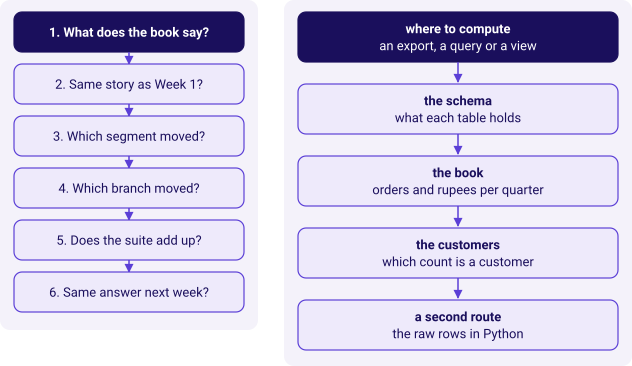

In [2]:
kit.side_by_side(
    kit.ladder(['What does the book say?', 'Same story as Week 1?', 'Which segment moved?', 'Which branch moved?', 'Does the suite add up?', 'Same answer next week?'], lit=0, show=False),
    kit.vflow(['where to compute\nan export, a query or a view', 'the schema\nwhat each table holds', 'the book\norders and rupees per quarter', 'the customers\nwhich count is a customer', 'a second route\nthe raw rows in Python'], lit=0, show=False),
)

## 1. The options: where could the Monday numbers be computed, and what does each way cost?

Three ways a team could put Anand's numbers on the Monday sheet. They differ in what moves each
Monday, in whether Anand's analyst can rerun exactly what the team ran, and in what
happens when the platform team renames a column in the warehouse.

| Option | What runs each Monday | Can the analyst rerun it? | When a column is renamed |
|---|---|---|---|
| A. Export the tables and compute in pandas, as Week 1 did | A copy of the tables leaves the warehouse, then Python runs on the copy | Only on the copy, which may no longer match the book | An old export keeps answering from old data; a fresh one breaks the pandas code |
| B. Query the warehouse from a `.sql` file | The file runs on the book and returns a few rows | Yes: the same file on the same book | The query stops with an error that names the missing column |
| C. Save the query as a view in the warehouse | The saved query runs on the book whenever the view is read | Yes: one line reads the view | The view follows a rename, and Postgres refuses to drop a column the view reads |

**Predict before you run.** For the quarter totals alone, how many rows does option A copy out
of the warehouse each Monday, against option B?

- a) The same number, since both answer the same question.
- b) A few more for A, since pandas needs a header row.
- c) Every row of the two tables the tree needs for A, and one row per quarter for B.
- d) Fewer for A, since an export is compressed.

option,rows that leave the warehouse each Monday
A. export and pandas,"1,340"
B. a .sql file,2
C. a saved view,2


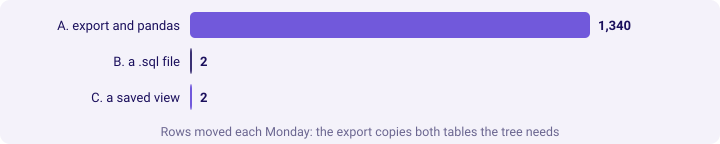

In [3]:
orders_rows =kit.sql("SELECT count(*) AS n FROM orders")[0]["n"]
customers_rows = kit.sql("SELECT count(*) AS n FROM customers")[0]["n"]
query_rows = len(kit.sql(Q["c1_book"]))
sizing = [("A. export and pandas", orders_rows + customers_rows),
          ("B. a .sql file", query_rows),
          ("C. a saved view", query_rows)]
kit.table(["option", "rows that leave the warehouse each Monday"],
          [(o, f"{n:,}") for o, n in sizing],
          caption="Sized on this warehouse: the rows each option moves for the quarter totals")
kit.bars(sizing, title="Rows moved each Monday: the export copies both tables the tree needs",
         lit=(1,))

**What happened.** The answer is c. An export copies all 1,000 order rows and all 340 customer
rows, 1,340 in all, before Python adds anything up; the query and the view send back two rows,
one per quarter. The copy is also a second version of the book, and the analyst cannot tell
whether it still matches the first.

**The best-fit call.** Option B, a `.sql` file queried every Monday. The platform lead granted
read access, and saving a view needs the right to create objects in the warehouse. The file
moves two rows where an export moves 1,340, the analyst reruns the same file on the same book,
and a renamed column stops it with an error instead of a quiet wrong number. The notebook you
are reading runs the same file, so it is where the team thinks, and the number on Anand's sheet
still comes from the query. **What would change the call:** once the suite stops changing and
the platform lead grants a schema to save it in, option C is better, because Postgres then
records which columns the Monday numbers depend on and refuses a change that would break them.

In [4]:
kit.check("an export moves every row of both tables", sizing[0][1] == 1340, f"{sizing[0][1]:,} rows")
kit.check("the query moves one row per quarter", query_rows == 2, f"{query_rows} rows")

## 2. What does the warehouse hold, and where does each leaf of the tree live?

Last week's file was one table of orders. The warehouse keeps each kind of record in its own table, and a number you cannot trace to a table
and a column is a number the analyst cannot audit.

**Predict before you run.** How many tables does the warehouse hold?

- a) One, the orders.
- b) Two, the orders and the customers.
- c) Seven.
- d) It cannot be known without asking the data team.

-- The question: which tables does the warehouse hold, and how many columns does each carry?
SELECT table_name, count(*) AS columns
FROM   information_schema.columns
WHERE  table_schema = 'public'
GROUP  BY table_name
ORDER  BY table_name;


table_name,columns
campaign_exposure,3
campaigns,5
customers,5
orders,7
payments,6
plan_line,2
refunds,5


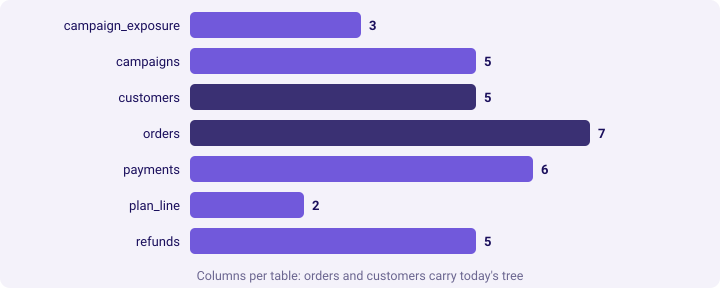

In [5]:
tables = run("c1_tables", "The warehouse's tables and how many columns each carries")
kit.bars([(t["table_name"], int(t["columns"])) for t in tables],
         title="Columns per table: orders and customers carry today's tree",
         lit=tuple(i for i, t in enumerate(tables) if t["table_name"] in ("orders", "customers")))

**What happened.** The answer is c: seven tables. Today's tree needs two of them, `orders` and
`customers`; the others arrive later in the week, each with its own question. The query that
listed them reads `information_schema`, the catalogue every Postgres database keeps about
itself, so nobody had to be asked.

In [6]:
cols = {r["column_name"]: r["data_type"] for r in run("c1_order_columns", "One order: its columns and their types")}
run("c1_peek", "The first five orders, by order id", money=("amount",))
kit.check("orders carries seven columns", len(cols) == 7, ", ".join(cols))
kit.check("amount is stored as a number, so SUM can add it", cols["amount"] == "numeric", cols["amount"])
kit.check("the segment is not on the order", "segment" not in cols, "it lives on the customer")

-- The question: what does one row of orders carry, and of which type is each column?
SELECT column_name, data_type
FROM   information_schema.columns
WHERE  table_schema = 'public' AND table_name = 'orders'
ORDER  BY ordinal_position;


column_name,data_type
order_id,text
customer_id,text
order_date,date
quarter,text
channel,text
amount,numeric
status,text


-- The question: what do the first five orders look like, by order id?
SELECT *
FROM   orders
ORDER  BY order_id
LIMIT  5;


order_id,customer_id,order_date,quarter,channel,amount,status
KR-00001,C-0316,2026-04-20,Q1,web,Rs 520,returned
KR-00002,C-0323,2026-05-19,Q1,app,Rs 800,delivered
KR-00003,C-0322,2026-06-08,Q1,store,Rs 800,cancelled
KR-00004,C-0325,2026-04-24,Q1,app,"Rs 1,310",delivered
KR-00005,C-0333,2026-05-27,Q1,app,"Rs 1,380",delivered


The segment lives on the customer, which chapter 3 needs: to report Retail-Plus, each order
looks up its customer's segment. Every leaf of today's tree comes from `orders`, and the count
of customers Kalpa holds comes from `customers`.

## 3. How many orders and rupees did each quarter book?

Week 1's extract said Rs 1,90,00,000 for Q1 and Rs 1,87,00,000 for Q2. The warehouse is the
whole book of the two quarters, so its totals are the ones Anand's sheet will carry.

**Predict before you run.** What will the warehouse say?

- a) Exactly the extract's two totals.
- b) Larger totals, falling the same 1.6 percent.
- c) Larger totals, falling by a different amount.
- d) Smaller totals, because the warehouse is de-duplicated.

-- The question: how many orders did each quarter book, and for how many rupees?
-- One row per quarter. Revenue is booked revenue, every status included.
SELECT quarter,
       count(*)                     AS orders,
       sum(amount)                  AS revenue,
       round(sum(amount) / count(*)) AS revenue_per_order
FROM   orders
GROUP  BY quarter
ORDER  BY quarter;


quarter,orders,revenue,revenue_per_order
Q1,538,"Rs 10,00,00,000","Rs 1,85,874"
Q2,462,"Rs 9,84,00,000","Rs 2,12,987"


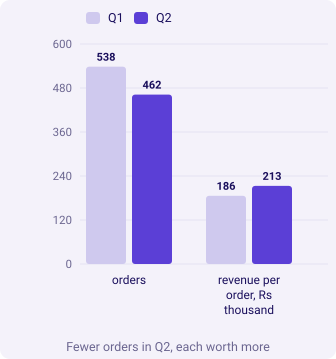

Revenue Rs 10,00,00,000 to Rs 9,84,00,000, -1.6 percent


In [7]:
book = {r["quarter"]: {k: num(v) for k, v in r.items()}
        for r in run("c1_book", "The book, one row per quarter", money=("revenue", "revenue_per_order"))}
q1, q2 = book["Q1"], book["Q2"]
kit.columns(["orders", "revenue per order, Rs thousand"],
            [("Q1", [q1["orders"], q1["revenue_per_order"] / 1000]),
             ("Q2", [q2["orders"], q2["revenue_per_order"] / 1000])],
            title="Fewer orders in Q2, each worth more", fmt=lambda v: f"{v:,.0f}")
print(f"Revenue {kit.rupees(q1['revenue'])} to {kit.rupees(q2['revenue'])}, "
      f"{pct(q1['revenue'], q2['revenue']):.1f} percent")

**What happened.** The answer is b. Q1 booked Rs 10,00,00,000 on 538 orders and Q2 booked
Rs 9,84,00,000 on 462: about five times the extract's totals, falling the same 1.6 percent.
Revenue per order rose from Rs 1,85,874 to Rs 2,12,987. One leaf agrees with Week 1, and
chapter 2 sets every other leaf beside last week's.

In [8]:
kit.check("the book holds 1,000 orders", q1["orders"] + q2["orders"] == 1000,
          f"{q1['orders']} and {q2['orders']}")
kit.check("Q1 booked Rs 10 crore", q1["revenue"] == 100000000, kit.rupees(q1["revenue"]))
kit.check("the fall is 1.6 percent", round(pct(q1["revenue"], q2["revenue"]), 1) == -1.6)
kit.check("revenue per order times orders gives the revenue back, to the rupee rounding",
          abs(q2["revenue_per_order"] * q2["orders"] - q2["revenue"]) <= q2["orders"],
          f"{q2['revenue_per_order']} x {q2['orders']}")

## 4. How many customers bought in each quarter?

The next leaf is customers, then orders per customer. A hurried analyst asks the table for its
customers the quickest way:

```sql
SELECT quarter, count(*) AS customers FROM orders GROUP BY quarter;
```

**Predict before you run.** What does that query count?

- a) The customers who bought in each quarter.
- b) The customers on Kalpa's customer table.
- c) The order rows in each quarter.
- d) The customers who bought more than once.

In [9]:
hurried = {r["quarter"]: int(r["customers"]) for r in run("c1_customers_hurried",
            "The hurried query, exactly as it would reach Anand's sheet")}
kit.stats([(f"{hurried['Q1']:,}", "Q1 customers", "the column's own label"),
           (f"{hurried['Q2']:,}", "Q2 customers", "the column's own label"),
           (f"{q1['orders'] / hurried['Q1']:.2f}", "orders per customer", "Q1 orders over that count"),
           (f"{q2['orders'] / hurried['Q2']:.2f}", "orders per customer", "Q2 orders over that count")],
          caption="The hurried reading of the customer leaf")

-- The question: how many customers bought in each quarter? (The quickest way to ask it.)
SELECT quarter, count(*) AS customers
FROM   orders
GROUP  BY quarter
ORDER  BY quarter;


quarter,customers
Q1,538
Q2,462


**The plausible wrong answer.** 538 customers in Q1 and 462 in Q2, each placing 1.00 order:
every customer bought once and never came back. On Anand's sheet the frequency branch, the one
Meera was told to fix, reads as if there were nothing to fix, and the case for spending the
Rs 12 crore on new customers comes back.

**Why it is wrong.** `count(*)` counts rows, and a row of `orders` is an order. The label
`AS customers` names the column and changes nothing the query counts, since the database prints
whatever name it is given. The answer is c.

**The check that exposes it.** Count the same table three ways, each count named for what it
counts, and set the customer table's own count beside them.

-- The check: the orders table counted two ways over both quarters, each count named for what it
-- counts. The next block, c1_members, adds the third count, from the customer table.
SELECT count(*)                    AS order_rows,
       count(DISTINCT customer_id) AS customers_who_bought
FROM   orders;


order_rows,customers_who_bought
1000,301


-- The question: how many customers does Kalpa hold on its customer table, bought or not?
SELECT count(*) AS customers_on_the_table
FROM   customers;


customers_on_the_table
340


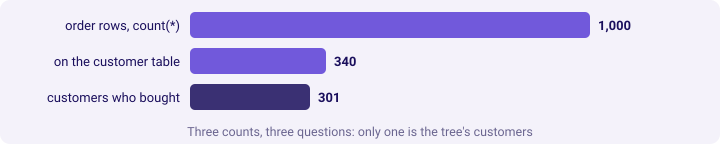

In [10]:
three = {k: int(v) for k, v in run("c1_three_counts", "One table, counted two ways")[0].items()}
members = int(run("c1_members", "The customer table's own count")[0]["customers_on_the_table"])
kit.bars([("order rows, count(*)", three["order_rows"]),
          ("on the customer table", members),
          ("customers who bought", three["customers_who_bought"])],
         title="Three counts, three questions: only one is the tree's customers", lit=(2,))

In [11]:
kit.check("order rows and customers are different counts",
          three["order_rows"] != three["customers_who_bought"],
          f"{three['order_rows']:,} rows, {three['customers_who_bought']} customers")
kit.check("301 customers bought across the two quarters", three["customers_who_bought"] == 301)
kit.check("39 customers on the customer table bought nothing in either quarter",
          members - three["customers_who_bought"] == 39, f"{members} less {three['customers_who_bought']}")

**The fix, and what it changed.** `count(DISTINCT customer_id)` counts each customer once. Run
per quarter, it gives the leaf the tree needs.

-- The fix: customers who bought in each quarter, each counted once, beside the order rows.
SELECT quarter,
       count(*)                    AS order_rows,
       count(DISTINCT customer_id) AS customers
FROM   orders
GROUP  BY quarter
ORDER  BY quarter;


quarter,order_rows,customers
Q1,538,244
Q2,462,227


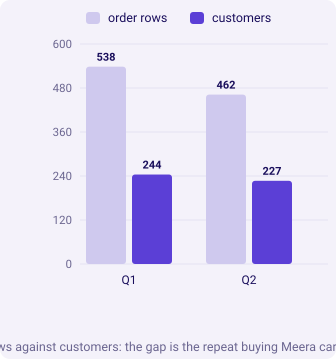

Q1: 244 customers, 2.20 orders each
Q2: 227 customers, 2.04 orders each


In [12]:
fixed = {r["quarter"]: {k: num(v) for k, v in r.items()}
         for r in run("c1_customers", "The customer leaf, beside the order rows it was confused with")}
kit.columns(["Q1", "Q2"],
            [("order rows", [fixed["Q1"]["order_rows"], fixed["Q2"]["order_rows"]]),
             ("customers", [fixed["Q1"]["customers"], fixed["Q2"]["customers"]])],
            title="Order rows against customers: the gap is the repeat buying Meera cares about")
for q in ("Q1", "Q2"):
    print(f"{q}: {fixed[q]['customers']} customers, "
          f"{fixed[q]['order_rows'] / fixed[q]['customers']:.2f} orders each")

**What happened.** 244 customers bought in Q1 and 227 in Q2, where the hurried query said 538
and 462. The fix takes 294 customers who do not exist out of Q1 and 235 out of Q2, and orders
per customer moves from 1.00 to 2.20 in Q1 and 2.04 in Q2: customers do come back, and the
frequency branch is on the sheet again. The customer table's 340 answers a different question,
how many customers Kalpa holds, and 39 of them bought nothing in either quarter.

In [13]:
kit.check("244 customers bought in Q1 and 227 in Q2",
          (fixed["Q1"]["customers"], fixed["Q2"]["customers"]) == (244, 227))
kit.check("orders per customer is above 1 in both quarters",
          all(fixed[q]["order_rows"] / fixed[q]["customers"] > 1 for q in ("Q1", "Q2")))
kit.check("the fix removes 294 and 235 customers who do not exist",
          (hurried["Q1"] - fixed["Q1"]["customers"], hurried["Q2"] - fixed["Q2"]["customers"]) == (294, 235))

## 5. A second route: do the raw rows, counted in Python, give the same leaves?

The second route answers the same three leaves without SQL's `count` and `sum`: it pulls every
order row into Python and counts with a set of customer ids and a running sum. It is option A
from the sizing, done once, so it also shows what an export costs.

**Predict before you run.** Will Python's set of ids per quarter give 244 and 227?

- a) Yes, since a set keeps each id once, as `count(DISTINCT ...)` does.
- b) No, since Python counts the rows.
- c) No, since Python rounds the amounts.
- d) Only if the rows arrive sorted.

In [14]:
rows = kit.sql(Q["c1_rows_for_python"])
py = {}
for r in rows:
    q = py.setdefault(r["quarter"], {"orders": 0, "ids": set(), "revenue": 0})
    q["orders"] += 1
    q["ids"].add(r["customer_id"])
    q["revenue"] += r["amount"]
kit.table(["leaf", "Q1, SQL", "Q1, Python", "Q2, SQL", "Q2, Python"],
          [("orders", q1["orders"], py["Q1"]["orders"], q2["orders"], py["Q2"]["orders"]),
           ("customers", fixed["Q1"]["customers"], len(py["Q1"]["ids"]),
            fixed["Q2"]["customers"], len(py["Q2"]["ids"])),
           ("revenue", kit.rupees(q1["revenue"]), kit.rupees(py["Q1"]["revenue"]),
            kit.rupees(q2["revenue"]), kit.rupees(py["Q2"]["revenue"]))],
          caption=f"Two routes, one book: Python moved {len(rows):,} rows to agree with two")

leaf,"Q1, SQL","Q1, Python","Q2, SQL","Q2, Python"
orders,538,538,462,462
customers,244,244,227,227
revenue,"Rs 10,00,00,000","Rs 10,00,00,000","Rs 9,84,00,000","Rs 9,84,00,000"


In [15]:
kit.check("Python's order counts agree with SQL's", (py["Q1"]["orders"], py["Q2"]["orders"]) == (538, 462))
kit.check("Python's sets of ids agree with count(DISTINCT)",
          (len(py["Q1"]["ids"]), len(py["Q2"]["ids"])) == (fixed["Q1"]["customers"], fixed["Q2"]["customers"]))
kit.check("Python's sums agree with SUM to the rupee",
          (py["Q1"]["revenue"], py["Q2"]["revenue"]) == (q1["revenue"], q2["revenue"]))
kit.check("the second route moved every order row", len(rows) == 1000, f"{len(rows):,} rows")

**What happened.** The answer is a. Both routes agree on 538 and 462 orders, 244 and 227
customers, and Rs 10,00,00,000 and Rs 9,84,00,000. The Python route moved 1,000 rows out of the
warehouse to reach what the query reached with two, which is why it is the check and the query
is the Monday way.

> **Kavya's review.** Every count says what it counts, in its name and in the comment above
> it. On Anand's sheet, customers means customers who bought in the quarter, each counted
> once, and the query's first line says so. A count named `customers` that counts rows is the
> one number an auditor finds first.

### In the interview: why compute a number in the warehouse, and how do you count customers there?

**[F] Why would you compute a KPI in the warehouse rather than in a notebook?** Because the
warehouse holds the one copy everybody reads. A query runs on that copy every time, so
Monday's number and the auditor's rerun come from the same book, and a renamed column stops
the query with an error. An export is a second copy that starts ageing the moment it lands,
and every number computed from it has to be traced back to it. On this warehouse the export
moves 1,340 rows to answer what the query answers with two. Exploration and charts stay in a
notebook that reads the warehouse; the reported number comes from the saved query.

**[F] What is the difference between `count(*)`, `count(customer_id)` and
`count(DISTINCT customer_id)`?** `count(*)` counts rows. `count(customer_id)` counts the rows
where `customer_id` is not missing. `count(DISTINCT customer_id)` counts the different ids
that are present. On Kalpa's orders the first two both give 1,000, since no order lacks a
customer, and the third gives 301 across the two quarters.

### Depth: what happens to a query and a view when the platform team renames a column?

The sizing table claimed that a query stops with an error and a view follows a rename. Your
Codespace's copy of the warehouse lets you watch both inside a transaction that is rolled
back, so the warehouse is left exactly as it was. The real warehouse would refuse these
statements to a read-only user; here they show the behaviour the table priced.

In [16]:
conn = kit.connect()
try:
    kit.sql("CREATE VIEW monday_book AS SELECT quarter, sum(amount) AS revenue FROM orders GROUP BY quarter", conn=conn)
    kit.sql("ALTER TABLE orders RENAME COLUMN amount TO amount_rs", conn=conn)
    view_after = kit.sql("SELECT pg_get_viewdef('monday_book') AS definition", conn=conn)[0]["definition"]
    with kit.expect_error() as renamed:
        kit.sql("SELECT sum(amount) FROM orders", conn=conn)
    conn.rollback()
    kit.sql("CREATE VIEW monday_book AS SELECT quarter, sum(amount) AS revenue FROM orders GROUP BY quarter", conn=conn)
    with kit.expect_error() as dropped:
        kit.sql("ALTER TABLE orders DROP COLUMN amount", conn=conn)
finally:
    conn.rollback()
    conn.close()
print("The view's definition after the rename:\n" + view_after)
kit.check("a query naming the old column stops with an error", renamed.name is not None, renamed.name)
kit.check("the view follows the rename", "amount_rs" in view_after)
kit.check("Postgres refuses to drop a column a view reads", dropped.name is not None, dropped.name)
kit.check("the warehouse is left as it was",
          "amount" in {r["column_name"] for r in kit.sql(Q["c1_order_columns"])})

The view's definition after the rename:
 SELECT quarter,
    sum(amount_rs) AS revenue
   FROM orders
  GROUP BY quarter;


The query naming `amount` stopped with an error the moment the column was renamed, the view
followed the rename, and Postgres refused to drop a column the view reads. That refusal is the
view's value and its cost: it protects Anand's number, and it makes the platform team ask
before changing anything the Monday numbers depend on.

## So how many orders, rupees and customers did each quarter book?

1. **Where should the Monday numbers be computed?** In a `.sql` file queried every Monday: two
   rows reach the screen where an export copies 1,340, the analyst reruns the same file on the
   same book, and a view takes over once the suite settles and a schema is granted.
2. **What does the warehouse hold?** Seven tables; today's tree needs `orders` and `customers`,
   and the segment lives on the customer.
3. **How many orders and rupees did each quarter book?** 538 orders and Rs 10,00,00,000 in Q1,
   462 orders and Rs 9,84,00,000 in Q2: down 1.6 percent, as Week 1 found.
4. **How many customers bought in each quarter?** 244 in Q1 and 227 in Q2, each counted once;
   `count(*)` said 538 and 462 because it counts orders.
5. **Do the raw rows in Python agree?** Yes, on every leaf, after moving 1,000 rows to do it.

Chapter 2 sets each of these leaves beside the ones Week 1's note to Meera rested on.

In [17]:
kit.check_summary()